# CME Futures: Feature Engineering

This notebook implements feature engineering for the CME Futures case study,
computing carry, momentum, volatility, seasonal, and composite features from
futures term structure data.

**Learning Objectives**:
- Build carry features from futures term structure (unique to this case study)
- Construct time-series and cross-sectional carry normalization
- Add seasonal features for agriculture and energy products
- Engineer roll proximity indicators from contract lifecycle
- Combine carry and momentum into composite signals

**Book Reference**: Chapter 8, Section 8.3 (Structural and Cross-Instrument Features)

**Prerequisites**: [`02_labels`](02_labels.ipynb) must have produced the label parquet
files and `config/cv_config.json`.

In [1]:
"""CME Futures: Feature Engineering."""

import subprocess
import warnings
from datetime import UTC, datetime

import numpy as np
import polars as pl
from ml4t.engineer.features.regime import variance_ratio as vr_func
from ml4t.engineer.features.volatility import yang_zhang_volatility

import utils.style as style
from data import load_cme_futures
from utils.paths import get_case_study_dir

# Importing utils.style registers the "ml4t" Plotly template as the default so
# every figure inherits the book font, backgrounds, gridlines, and colorway.
warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI

In [3]:

CASE_DIR = get_case_study_dir("cme_futures")
FEATURES_DIR = CASE_DIR / "features"
STRATEGY_ID = "cme_futures"

# Feature configuration
MOMENTUM_HORIZONS = [5, 21, 63, 126, 252]  # 1w, 1m, 3m, 6m, 12m
VOLATILITY_HORIZONS = [21, 63, 126]  # 1m, 3m, 6m

# Product-to-sector mapping
PRODUCT_GROUPS = {
    "equity_index": ["ES", "NQ", "YM", "RTY"],
    "treasuries": ["ZN", "ZB", "ZF", "ZT"],
    "energy": ["CL", "NG", "HO", "RB"],
    "metals": ["GC", "SI", "HG", "PL"],
    "currencies": ["6E", "6J", "6B", "6A", "6C", "6S"],
    "agriculture": ["ZC", "ZS", "ZW", "ZM", "ZL"],
    "livestock": ["LE", "HE", "GF"],
}
PRODUCT_TO_SECTOR = {}
for sector, products in PRODUCT_GROUPS.items():
    for p in products:
        PRODUCT_TO_SECTOR[p] = sector

# Seasonal sectors (agriculture and energy have well-documented seasonality)
SEASONAL_SECTORS = {"agriculture", "energy"}

## 1. Load Futures Term Structure Data

We load session-aligned daily data with three contract tenors per product.
The `tenor` column (renamed to `position`) indicates the contract:
- position 0 = front month (c0, nearest to expiry)
- position 1 = second month (c1)
- position 2 = third month (c2)

In [4]:
df = load_cme_futures().rename({"session_date": "timestamp", "tenor": "position"})

print(f"Loaded {len(df):,} rows")
print(f"Products: {sorted(df['product'].unique().to_list())}")
print(f"Positions: {sorted(df['position'].unique().to_list())}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Loaded 312,859 rows
Products: ['6A', '6B', '6C', '6E', '6J', '6S', 'CL', 'ES', 'GC', 'GF', 'HE', 'HG', 'HO', 'LE', 'NG', 'NQ', 'PL', 'RB', 'RTY', 'SI', 'YM', 'ZB', 'ZC', 'ZF', 'ZL', 'ZM', 'ZN', 'ZS', 'ZT', 'ZW']
Positions: [0, 1, 2]
Date range: 2011-01-03 to 2025-12-31


## 2. Carry Features from Term Structure

Carry is computed from the price difference between front and second month:

$$\text{carry}_t = \frac{F_1 - F_2}{F_1} \times 12$$

This is a product-level feature (same value across all positions for a
product-date). We compute raw carry, smoothed carry, cross-sectional rank,
**time-series z-score**, **sector-conditional normalization**, and curve
curvature from the third contract.

In [5]:
def compute_carry_features(data: pl.DataFrame) -> pl.DataFrame:
    """Compute carry and curve features from term structure.

    Returns product-date level features to be joined to all positions.
    """
    # Extract front, second, and third month prices from the RAW (unadjusted)
    # close. Term structure is a spread between contemporaneous tenor *levels*;
    # the ratio-adjusted `close` bakes in each tenor's accumulated roll history,
    # so differencing adjusted levels measures roll history, not the curve. Carry,
    # curvature, and roll proximity must all read raw_close. (Returns/momentum use
    # the adjusted close elsewhere — ratio adjustment preserves within-tenor returns.)
    front = (
        data.filter(pl.col("position") == 0)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c0_price"})
    )
    second = (
        data.filter(pl.col("position") == 1)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c1_price"})
    )
    third = (
        data.filter(pl.col("position") == 2)
        .select(["product", "timestamp", "raw_close"])
        .rename({"raw_close": "c2_price"})
    )

    carry_df = front.join(second, on=["product", "timestamp"], how="inner")
    carry_df = carry_df.join(third, on=["product", "timestamp"], how="left")

    # --- Raw carry and curve ---
    # Null out where prices <= 0 (CL went negative 2020-04-20)
    carry_df = carry_df.with_columns(
        # Carry percentage (annualized assuming monthly rolls)
        pl.when(pl.col("c0_price") > 0)
        .then((pl.col("c0_price") - pl.col("c1_price")) / pl.col("c0_price") * 12)
        .otherwise(None)
        .alias("carry_pct"),
        # Curve curvature: c0 - 2*c1 + c2 (second derivative)
        pl.when(pl.col("c1_price") > 0)
        .then(
            (pl.col("c0_price") - 2 * pl.col("c1_price") + pl.col("c2_price")) / pl.col("c1_price")
        )
        .otherwise(None)
        .alias("curve_curvature_norm"),
    )

    # Numeric carry regime (1=backwardation, 0=neutral, -1=contango)
    carry_df = carry_df.with_columns(
        pl.when(pl.col("carry_pct") > 0.01)
        .then(1)
        .when(pl.col("carry_pct") < -0.01)
        .then(-1)
        .otherwise(0)
        .alias("carry_regime_num")
    )

    # --- Smoothed carry and curvature ---
    carry_df = carry_df.sort(["product", "timestamp"])
    carry_df = carry_df.with_columns(
        pl.col("carry_pct").rolling_mean(window_size=21).over("product").alias("carry_21d"),
        pl.col("curve_curvature_norm")
        .rolling_mean(window_size=21)
        .over("product")
        .alias("curvature_21d"),
    )

    # --- Carry momentum (change in carry over time) ---
    carry_df = carry_df.with_columns(
        (pl.col("carry_21d") - pl.col("carry_21d").shift(5).over("product")).alias(
            "carry_momentum_5d"
        ),
        (pl.col("carry_21d") - pl.col("carry_21d").shift(21).over("product")).alias(
            "carry_momentum_21d"
        ),
    )

    # --- Carry z-score (time-series normalization) ---
    # Captures whether current carry is historically high or low FOR THIS PRODUCT.
    # This is the primary mean-reversion signal per Koijen et al. (2018).
    carry_df = carry_df.with_columns(
        (
            (pl.col("carry_21d") - pl.col("carry_21d").rolling_mean(63).over("product"))
            / pl.col("carry_21d").rolling_std(63).over("product").clip(lower_bound=1e-6)
        )
        .clip(lower_bound=-5.0, upper_bound=5.0)
        .alias("carry_zscore_63d"),
        (
            (pl.col("carry_21d") - pl.col("carry_21d").rolling_mean(126).over("product"))
            / pl.col("carry_21d").rolling_std(126).over("product").clip(lower_bound=1e-6)
        )
        .clip(lower_bound=-5.0, upper_bound=5.0)
        .alias("carry_zscore_126d"),
    )

    # --- Cross-sectional carry rank ---
    carry_df = carry_df.with_columns(
        (
            pl.col("carry_pct").rank().over("timestamp")
            / pl.col("carry_pct").count().over("timestamp")
        ).alias("carry_rank"),
        (
            pl.col("curve_curvature_norm").rank().over("timestamp")
            / pl.col("curve_curvature_norm").count().over("timestamp")
        ).alias("curvature_rank"),
    )

    # --- Sector-conditional carry normalization ---
    # Add sector column for within-sector ranking
    carry_df = carry_df.with_columns(
        pl.col("product").replace_strict(PRODUCT_TO_SECTOR, default="unknown").alias("_sector")
    )
    # Rank carry within sector (e.g., CL rank among energy products)
    carry_df = carry_df.with_columns(
        (
            pl.col("carry_pct").rank().over(["timestamp", "_sector"])
            / pl.col("carry_pct").count().over(["timestamp", "_sector"])
        ).alias("carry_rank_sector")
    )
    carry_df = carry_df.drop("_sector")

    return carry_df.select(
        [
            "product",
            "timestamp",
            "carry_pct",
            "carry_regime_num",
            "carry_21d",
            "carry_momentum_5d",
            "carry_momentum_21d",
            "carry_zscore_63d",
            "carry_zscore_126d",
            "carry_rank",
            "carry_rank_sector",
            "curve_curvature_norm",
            "curvature_21d",
            "curvature_rank",
        ]
    )


carry_features = compute_carry_features(df)
print(f"Carry features: {len(carry_features):,} product-dates")
print(f"  Columns: {carry_features.columns}")

Carry features: 111,440 product-dates
  Columns: ['product', 'timestamp', 'carry_pct', 'carry_regime_num', 'carry_21d', 'carry_momentum_5d', 'carry_momentum_21d', 'carry_zscore_63d', 'carry_zscore_126d', 'carry_rank', 'carry_rank_sector', 'curve_curvature_norm', 'curvature_21d', 'curvature_rank']


## 3. Position-Level Features

Momentum, volatility, and technical features computed per position.
Each position has its own price series.

In [6]:
def compute_position_features(data: pl.DataFrame) -> pl.DataFrame:
    """Compute per-position features for ML.

    Categories: momentum, volatility, Sharpe ratios, RSI, MA ratios,
    time-series momentum signals, and cross-sectional ranks.
    """
    data = data.sort(["product", "position", "timestamp"])

    # === 1. Multi-horizon momentum ===
    # Null out returns where lagged price <= 0 (CL went negative 2020-04-20)
    for h in MOMENTUM_HORIZONS:
        lagged = pl.col("adj_close").shift(h).over(["product", "position"])
        data = data.with_columns(
            pl.when(lagged > 0)
            .then(pl.col("adj_close") / lagged - 1)
            .otherwise(None)
            .alias(f"ret_{h}d")
        )

    # Skip-month momentum (12-1): the return from t-252 to t-21, which avoids
    # short-term reversal. Returns compound, so the recent month is removed by
    # dividing prices, not by subtracting ret_21d from ret_252d. Same
    # negative-price guard as the multi-horizon returns above.
    _skip_end = pl.col("adj_close").shift(21).over(["product", "position"])
    _skip_start = pl.col("adj_close").shift(252).over(["product", "position"])
    data = data.with_columns(
        pl.when((_skip_start > 0) & (_skip_end > 0))
        .then(_skip_end / _skip_start - 1)
        .otherwise(None)
        .alias("skip_month_mom")
    )

    # Daily returns for volatility
    lagged_1d = pl.col("adj_close").shift(1).over(["product", "position"])
    data = data.with_columns(
        pl.when(lagged_1d > 0)
        .then(pl.col("adj_close") / lagged_1d - 1)
        .otherwise(None)
        .alias("daily_ret")
    )

    # === 2. Multi-horizon volatility ===
    for h in VOLATILITY_HORIZONS:
        data = data.with_columns(
            (
                pl.col("daily_ret").rolling_std(window_size=h).over(["product", "position"])
                * np.sqrt(252)
            ).alias(f"vol_{h}d")
        )

    # Volatility ratios
    data = data.with_columns(
        (pl.col("vol_21d") / pl.col("vol_63d").clip(lower_bound=1e-6))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_short"),
        (pl.col("vol_63d") / pl.col("vol_126d").clip(lower_bound=1e-6))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_medium"),
    )

    # Yang-Zhang volatility (more efficient for OHLC data) and variance ratio
    vr_exprs = vr_func("adj_close", periods=[5], window=63)
    data = data.with_columns(
        yang_zhang_volatility(
            "adj_open", "adj_high", "adj_low", "adj_close", period=21, annualize=True
        )
        .over(["product", "position"])
        .alias("vol_yz_21d"),
        vr_exprs["vr_5"].over(["product", "position"]).alias("vr_63d"),
    )

    # === 3. Sharpe-like ratios ===
    for h in MOMENTUM_HORIZONS:
        if h >= 21:
            vol_h = min(
                [v for v in VOLATILITY_HORIZONS if v <= h],
                default=21,
                key=lambda x: abs(x - h),
            )
            data = data.with_columns(
                (pl.col(f"ret_{h}d") / pl.col(f"vol_{vol_h}d").clip(lower_bound=0.01))
                .clip(lower_bound=-10.0, upper_bound=10.0)
                .alias(f"sharpe_{h}d")
            )

    # === 4. Momentum acceleration ===
    data = data.with_columns(
        (pl.col("ret_21d") - pl.col("ret_63d")).alias("mom_accel_short"),
        (pl.col("ret_63d") - pl.col("ret_126d")).alias("mom_accel_medium"),
        (pl.col("ret_126d") - pl.col("ret_252d")).alias("mom_accel_long"),
    )

    # === 5. RSI ===
    gain = pl.when(pl.col("daily_ret") > 0).then(pl.col("daily_ret")).otherwise(0)
    loss = pl.when(pl.col("daily_ret") < 0).then(pl.col("daily_ret").abs()).otherwise(0)
    data = data.with_columns(
        gain.rolling_mean(14).over(["product", "position"]).alias("_avg_gain"),
        loss.rolling_mean(14).over(["product", "position"]).alias("_avg_loss"),
    )
    data = data.with_columns(
        (100 - (100 / (1 + pl.col("_avg_gain") / (pl.col("_avg_loss") + 1e-8)))).alias("rsi_14")
    )
    data = data.drop(["_avg_gain", "_avg_loss"])

    # === 6. Moving average ratios and distance from extremes ===
    # Guard against negative prices (CL 2020-04-20) in denominators
    for period in [21, 50, 200]:
        ma = pl.col("adj_close").rolling_mean(period).over(["product", "position"])
        data = data.with_columns(
            pl.when(ma > 0)
            .then(pl.col("adj_close") / ma)
            .otherwise(None)
            .alias(f"ma_ratio_{period}")
        )

    roll_max = pl.col("adj_close").rolling_max(252).over(["product", "position"])
    roll_min = pl.col("adj_close").rolling_min(126).over(["product", "position"])
    data = data.with_columns(
        pl.when(roll_max > 0)
        .then(pl.col("adj_close") / roll_max)
        .otherwise(None)
        .alias("dist_from_52w_high"),
        pl.when(roll_min > 0)
        .then(pl.col("adj_close") / roll_min)
        .otherwise(None)
        .alias("dist_from_6m_low"),
    )

    # === 7. Time-series momentum signals ===
    for h in [63, 126, 252]:
        data = data.with_columns(
            pl.when(pl.col(f"ret_{h}d") > 0)
            .then(pl.lit(1))
            .when(pl.col(f"ret_{h}d") < 0)
            .then(pl.lit(-1))
            .otherwise(pl.lit(0))
            .alias(f"ts_mom_{h}d")
        )

    # === 8. Cross-sectional ranks ===
    for h in [21, 63, 126, 252]:
        data = data.with_columns(
            (
                pl.col(f"ret_{h}d").rank().over(["timestamp", "position"])
                / pl.col(f"ret_{h}d").count().over(["timestamp", "position"])
            ).alias(f"mom_rank_{h}d")
        )

    for h in [63, 126, 252]:
        data = data.with_columns(
            (
                pl.col(f"sharpe_{h}d").rank().over(["timestamp", "position"])
                / pl.col(f"sharpe_{h}d").count().over(["timestamp", "position"])
            ).alias(f"sharpe_rank_{h}d")
        )

    data = data.with_columns(
        (
            pl.col("vol_21d").rank().over(["timestamp", "position"])
            / pl.col("vol_21d").count().over(["timestamp", "position"])
        ).alias("vol_rank"),
        (
            pl.col("rsi_14").rank().over(["timestamp", "position"])
            / pl.col("rsi_14").count().over(["timestamp", "position"])
        ).alias("rsi_rank"),
    )

    # === 9. Composite factors ===
    data = data.with_columns(
        ((pl.col("mom_rank_63d") + pl.col("mom_rank_126d") + pl.col("mom_rank_252d")) / 3).alias(
            "momentum_composite"
        ),
        (
            (pl.col("sharpe_rank_63d") + pl.col("sharpe_rank_126d") + pl.col("sharpe_rank_252d"))
            / 3
        ).alias("sharpe_composite"),
    )

    return data


df_features = compute_position_features(df)
print(f"Position features: {len(df_features):,} rows")

Position features: 312,859 rows


## 4. Calendar and Seasonal Features

Agriculture (ZC, ZS, ZW) and energy (CL, NG) have well-documented seasonal
patterns driven by planting/harvest cycles and heating/cooling demand.
We encode month-of-year using sin/cos for continuity (December is close to
January on the circle), and add a roll-proximity indicator.

In [7]:
def compute_calendar_features(data: pl.DataFrame) -> pl.DataFrame:
    """Add calendar and seasonal features.

    - Month sin/cos encoding (continuous circular representation)
    - Seasonal sector flag (1 for agriculture/energy, 0 otherwise)
    - Roll proximity indicator (binary: within 5 days of typical roll)
    - Quarter dummy
    """
    data = data.with_columns(
        # Month sin/cos (continuous encoding, period = 12 months)
        (2 * np.pi * pl.col("timestamp").dt.month().cast(pl.Float64) / 12).sin().alias("month_sin"),
        (2 * np.pi * pl.col("timestamp").dt.month().cast(pl.Float64) / 12).cos().alias("month_cos"),
        # Day of year (normalized to [0, 1])
        (pl.col("timestamp").dt.ordinal_day().cast(pl.Float64) / 365.25).alias("day_of_year_norm"),
        # Quarter (1-4)
        pl.col("timestamp").dt.quarter().cast(pl.Float64).alias("quarter"),
    )

    # Seasonal sector flag (agriculture and energy have strong seasonality)
    data = data.with_columns(
        pl.col("product").replace_strict(PRODUCT_TO_SECTOR, default="unknown").alias("_sector_temp")
    )
    data = data.with_columns(
        pl.col("_sector_temp")
        .is_in(list(SEASONAL_SECTORS))
        .cast(pl.Float64)
        .alias("is_seasonal_sector")
    )
    data = data.drop("_sector_temp")

    # Roll proximity: flag when within 5 business days of month end.
    # CME rolls are typically 5 days before expiry; for monthly contracts,
    # this approximates the last week of the month.
    data = data.with_columns(
        pl.when(pl.col("timestamp").dt.day() >= 25).then(1.0).otherwise(0.0).alias("roll_proximity")
    )

    return data


df_features = compute_calendar_features(df_features)
print("Calendar features added: month_sin, month_cos, roll_proximity, etc.")

Calendar features added: month_sin, month_cos, roll_proximity, etc.


## 5. Join Carry to All Positions and Build Composites

Carry is a term-structure feature (same value for all positions of a
product-date). After joining, we build carry-momentum interaction terms.

In [8]:
def create_combined_signals(data: pl.DataFrame) -> pl.DataFrame:
    """Create carry-momentum composites and interaction terms."""
    # Carry-momentum composite (equal weight of carry rank and momentum rank)
    data = data.with_columns(
        ((pl.col("carry_rank") + pl.col("momentum_composite")) / 2).alias("carry_mom_composite")
    )

    # Risk-adjusted composite (favor low volatility)
    data = data.with_columns(
        (pl.col("carry_mom_composite") / (pl.col("vol_rank") + 0.1)).alias("risk_adj_score")
    )

    # Momentum-carry interaction: product of carry z-score and momentum
    # This captures whether carry and momentum agree (confirming) or disagree
    data = data.with_columns(
        (pl.col("carry_zscore_63d") * pl.col("momentum_composite")).alias("carry_mom_interaction")
    )

    # Long/short signal based on composite (naive threshold for illustration)
    data = data.with_columns(
        pl.when(pl.col("carry_mom_composite") > 0.6)
        .then(pl.lit(1))
        .when(pl.col("carry_mom_composite") < 0.4)
        .then(pl.lit(-1))
        .otherwise(pl.lit(0))
        .alias("ls_signal")
    )

    return data


# Join carry to all positions
df_combined = df_features.join(carry_features, on=["product", "timestamp"], how="left")
df_final = create_combined_signals(df_combined)

print(f"Combined features: {len(df_final):,} rows")
print(f"Products: {df_final['product'].n_unique()}, Positions: {df_final['position'].n_unique()}")

Combined features: 312,859 rows
Products: 30, Positions: 3


## 6. Feature Selection and Output

We exclude raw prices (non-stationary), metadata columns, and intermediate
calculations, keeping only the engineered features.

In [9]:
# Columns to exclude from feature matrix
metadata_cols = {
    "timestamp",
    "product",
    "position",
    "underlying",
    "ts_event",
    # Raw prices (non-stationary)
    "open",
    "high",
    "low",
    "close",
    "volume",
    "adj_open",
    "adj_high",
    "adj_low",
    "adj_close",
    # Unadjusted OHLC + roll multiplier carried by the session-aggregation fix:
    # used to build carry/term-structure features, never a model feature themselves.
    "raw_open",
    "raw_high",
    "raw_low",
    "raw_close",
    "cum_ratio",
    # Session metadata
    "bar_count",
    "session_start",
    "session_end",
    # Intermediate calculations
    "daily_ret",
    "carry_spread",
    "carry_regime",
    "front_price",
    "second_price",
}

feature_cols = sorted(c for c in df_final.columns if c not in metadata_cols)
output_cols = ["timestamp", "product", "position"] + feature_cols
available_cols = [c for c in output_cols if c in df_final.columns]

# Drop nulls for essential short-lookback features
essential_cols = ["timestamp", "product", "position", "ret_21d", "vol_21d"]
essential_cols = [c for c in essential_cols if c in available_cols]
output_df = df_final.select(available_cols).drop_nulls(subset=essential_cols)

n_features = len(feature_cols)
print(f"Features: {n_features} ({len(output_df):,} rows)")
print(f"Products: {output_df['product'].n_unique()}")
print(f"Positions: {sorted(output_df['position'].unique().to_list())}")
print(f"Date range: {output_df['timestamp'].min()} to {output_df['timestamp'].max()}")

# Feature breakdown by family
carry_feats = [c for c in feature_cols if "carry" in c and "regime" not in c]
mom_feats = [c for c in feature_cols if c.startswith("ret_") or "mom" in c.lower()]
vol_feats = [c for c in feature_cols if c.startswith("vol_") or c == "vr_63d"]
sharpe_feats = [c for c in feature_cols if "sharpe" in c]
tech_feats = [c for c in feature_cols if any(c.startswith(p) for p in ["rsi_", "ma_ratio"])]
rank_feats = [c for c in feature_cols if "rank" in c]
calendar_feats = [
    c
    for c in feature_cols
    if any(k in c for k in ["month_", "quarter", "roll_", "season", "day_of_year"])
]

print("\nFeature breakdown:")
print(f"  Carry/Term Structure: {len(carry_feats)}")
print(f"  Momentum: {len(mom_feats)}")
print(f"  Volatility: {len(vol_feats)}")
print(f"  Sharpe: {len(sharpe_feats)}")
print(f"  Technical: {len(tech_feats)}")
print(f"  Ranks: {len(rank_feats)}")
print(f"  Calendar/Seasonal: {len(calendar_feats)}")

Features: 62 (310,948 rows)
Products: 30
Positions: [0, 1, 2]
Date range: 2011-02-01 to 2025-12-31

Feature breakdown:
  Carry/Term Structure: 10
  Momentum: 21
  Volatility: 8
  Sharpe: 8
  Technical: 5
  Ranks: 12
  Calendar/Seasonal: 7


## 7. Save Features

In [10]:
output_path = FEATURES_DIR / "financial.parquet"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
output_df.write_parquet(output_path)
print(f"Saved {n_features} features to {output_path}")

Saved 62 features to /home/stefan/ml4t/public-release-candidate/case_studies/cme_futures/features/financial.parquet


## 8. Feature Evaluation

We evaluate engineered features against forward return labels using:
- **Information Coefficient (IC)**: Spearman rank correlation between feature and label
- **HAC adjustment**: Newey-West standard errors accounting for overlapping returns
- **BH-FDR**: Benjamini-Hochberg false discovery rate for multiple testing
- **Pairwise correlation**: Identify redundant feature pairs

We compute cross-sectional IC: for each date, rank-correlate feature values
across the 30 products (front-month only). HAC adjustment is critical because
overlapping 5-day returns create autocorrelation in the IC series.

> **Descriptive diagnostic, not an out-of-sample estimate.** These ICs are
> computed over the **full sample** (2011–2025, including the sealed holdout) as
> a sanity check on the engineered features; they drive **no** feature selection
> (every feature is written to `financial.parquet` above, before this section).
> The authoritative, holdout-clean feature evaluation is
> [`05_evaluation`](05_evaluation.ipynb) — treat the numbers here as in-sample
> exploration, not as unbiased predictive performance.

In [11]:
import plotly.graph_objects as go
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats

### Load Labels and Join

In [12]:
LABELS_DIR = CASE_DIR / "labels"
label_ret5d = pl.read_parquet(LABELS_DIR / "fwd_ret_5d.parquet")

PRIMARY_LABEL = "fwd_ret_5d"

# Front-month features joined with primary label
eval_df = output_df.filter(pl.col("position") == 0).join(
    label_ret5d, on=["timestamp", "product", "position"], how="inner"
)
print(f"Evaluation data: {eval_df.shape} (front-month, {eval_df['product'].n_unique()} products)")

Evaluation data: (112726, 66) (front-month, 30 products)


### Compute Per-Feature IC

We use `pl.corr()` grouped by date to compute cross-sectional Spearman IC
natively in Polars, avoiding the cross-product join bug in `cross_sectional_ic_series`
for panel data. The IC time series is then fed to `compute_ic_hac_stats()`
for Newey-West standard errors.

Calendar features (month, quarter, day-of-year) have no within-date variation
across products and will produce null IC values — this is expected.

In [13]:
def assign_feature_family(name: str) -> str:
    """Map feature name to family based on prefix/substring."""
    if any(k in name for k in ["carry", "curvature"]):
        return "carry"
    if name.startswith("ret_") or "mom" in name.lower():
        return "momentum"
    if name.startswith("vol_") or name in ("vr_63d",):
        return "volatility"
    if "sharpe" in name:
        return "sharpe"
    if any(name.startswith(p) for p in ["rsi", "ma_ratio", "dist_from", "ts_mom"]):
        return "technical"
    if any(k in name for k in ["month_", "quarter", "roll_", "season", "day_of_year"]):
        return "calendar"
    if any(k in name for k in ["rank", "composite", "ls_signal", "risk_adj"]):
        return "cross_sectional"
    return "other"

In [14]:
def compute_ic_summary(
    data: pl.DataFrame,
    features: list[str],
    label_col: str,
    min_obs: int = 10,
) -> dict[str, dict]:
    """Compute cross-sectional IC for each feature against a label.

    Uses Polars group_by + pl.corr() to avoid the cross-product join bug
    in cross_sectional_ic_series for panel data.
    """
    results = {}
    for feat in features:
        valid = data.filter(pl.col(feat).is_not_null() & pl.col(label_col).is_not_null())

        ic_series = (
            valid.group_by("timestamp")
            .agg(pl.corr(feat, label_col, method="spearman").alias("ic"), pl.len().alias("n_obs"))
            .filter(pl.col("n_obs") >= min_obs)
            .drop_nulls("ic")
            .sort("timestamp")
        )

        if len(ic_series) >= 20:
            stats = compute_ic_hac_stats(ic_series, ic_col="ic")
            # Skip features where HAC stats are NaN (e.g., constant within-date values)
            if not np.isnan(stats["mean_ic"]):
                results[feat] = stats
    return results

In [15]:
ic_results = compute_ic_summary(eval_df, feature_cols, PRIMARY_LABEL)
print(f"Computed IC for {len(ic_results)}/{len(feature_cols)} features")

Computed IC for 57/62 features


### Apply BH-FDR Correction

In [16]:
tested_features = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in tested_features]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": tested_features,
        "family": [assign_feature_family(f) for f in tested_features],
        "ic_mean": [ic_results[f]["mean_ic"] for f in tested_features],
        "hac_se": [ic_results[f]["hac_se"] for f in tested_features],
        "hac_tstat": [ic_results[f]["t_stat"] for f in tested_features],
        "p_value": p_values,
        "adjusted_p": fdr_result["adjusted_p_values"].tolist(),
        "significant_fdr05": fdr_result["rejected"].tolist(),
        "naive_se": [ic_results[f]["naive_se"] for f in tested_features],
        "naive_tstat": [ic_results[f]["naive_t_stat"] for f in tested_features],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_tstat": pl.Float64,
        "p_value": pl.Float64,
        "adjusted_p": pl.Float64,
        "naive_se": pl.Float64,
        "naive_tstat": pl.Float64,
    },
)
if len(eval_summary) > 0:
    eval_summary = eval_summary.sort(pl.col("ic_mean").abs(), descending=True)

n_significant = int(fdr_result["n_rejected"])
n_naive_sig = sum(1 for p in p_values if p < 0.05)

print(f"Features tested: {len(tested_features)}")
print(f"Naive significant (p < 0.05): {n_naive_sig}")
print(f"FDR-corrected significant: {n_significant}")
print(f"Inflation factor: {n_naive_sig / max(n_significant, 1):.1f}x")
print("\nTop 10 features by IC:")
print(eval_summary.head(10))

Features tested: 57
Naive significant (p < 0.05): 10
FDR-corrected significant: 4
Inflation factor: 2.5x

Top 10 features by IC:
shape: (10, 10)
┌────────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ feature    ┆ family    ┆ ic_mean   ┆ hac_se   ┆ … ┆ adjusted_ ┆ significa ┆ naive_se ┆ naive_tst │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆   ┆ p         ┆ nt_fdr05  ┆ ---      ┆ at        │
│ str        ┆ str       ┆ f64       ┆ f64      ┆   ┆ ---       ┆ ---       ┆ f64      ┆ ---       │
│            ┆           ┆           ┆          ┆   ┆ f64       ┆ bool      ┆          ┆ f64       │
╞════════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ mom_accel_ ┆ momentum  ┆ -0.043182 ┆ 0.009788 ┆ … ┆ 0.000602  ┆ true      ┆ 0.005055 ┆ -8.542863 │
│ long       ┆           ┆           ┆          ┆   ┆           ┆           ┆          ┆           │
│ skip_month ┆ momentum  ┆ 0.031164  ┆ 0.009848

### Carry IC Validation

The concept note claims carry IC ~ 0.099. We compare against the empirical
carry feature ICs for the primary label (`fwd_ret_5d`, total return including
roll yield).

In [17]:
carry_features_list = [f for f in tested_features if assign_feature_family(f) == "carry"]

print("Carry feature IC for fwd_ret_5d (total return):")
print(f"{'Feature':<25} {'IC':>12}")
print("-" * 40)
for feat in carry_features_list:
    ic_total = ic_results.get(feat, {}).get("mean_ic", float("nan"))
    print(f"{feat:<25} {ic_total:>12.4f}")

concept_claim = 0.099
best_carry_ic = max(
    (abs(ic_results[f]["mean_ic"]) for f in carry_features_list if f in ic_results), default=0
)
print(f"\nBest carry |IC|: {best_carry_ic:.4f} (concept note claim: {concept_claim})")
if best_carry_ic > concept_claim * 2:
    print("WARNING: Empirical carry IC >2x concept note claim — investigate")
elif best_carry_ic < concept_claim / 2:
    print("WARNING: Empirical carry IC <0.5x concept note claim — investigate")

Carry feature IC for fwd_ret_5d (total return):
Feature                             IC
----------------------------------------
carry_21d                       0.0165
carry_mom_composite             0.0117
carry_mom_interaction          -0.0028
carry_momentum_21d             -0.0068
carry_momentum_5d              -0.0166
carry_pct                       0.0054
carry_rank                      0.0054
carry_rank_sector               0.0010
carry_regime_num                0.0067
carry_zscore_126d               0.0048
carry_zscore_63d               -0.0015
curvature_21d                   0.0028
curvature_rank                 -0.0040
curve_curvature_norm           -0.0040

Best carry |IC|: 0.0166 (concept note claim: 0.099)


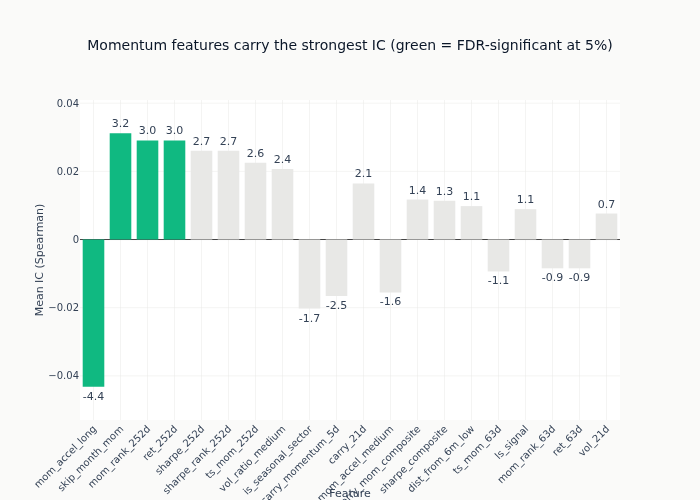

In [18]:
# IC bar chart (top 20 by absolute IC)
top_20 = (
    eval_summary.sort(pl.col("ic_mean").abs(), descending=True).head(20)
    if len(eval_summary) > 0
    else eval_summary.head(0)
)

colors = [
    style.COLORS["positive"] if sig else style.COLORS["silver_muted"]
    for sig in top_20["significant_fdr05"].to_list()
]
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=top_20["feature"].to_list(),
        y=top_20["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"{t:.1f}" for t in top_20["hac_tstat"].to_list()],
        textposition="outside",
    )
)
fig.update_layout(
    title="Momentum features carry the strongest IC (green = FDR-significant at 5%)",
    xaxis_title="Feature",
    yaxis_title="Mean IC (Spearman)",
    template="ml4t",
    xaxis_tickangle=-45,
    height=500,
)
fig.show()

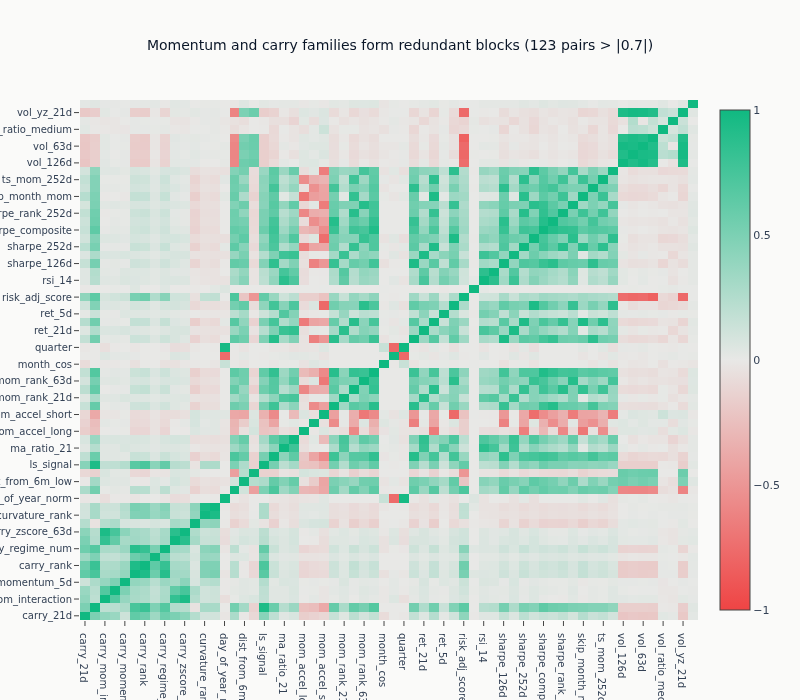


123 feature pairs with |corr| > 0.7:
  vol_21d -- vol_yz_21d: 0.974
  vol_126d -- vol_63d: 0.972
  day_of_year_norm -- quarter: 0.968
  vol_63d -- vol_yz_21d: 0.961
  vol_21d -- vol_63d: 0.953
  curvature_rank -- curve_curvature_norm: 0.947
  carry_mom_interaction -- carry_zscore_63d: 0.944
  vol_21d -- vol_rank: 0.942
  carry_mom_composite -- ls_signal: 0.941
  ret_252d -- skip_month_mom: 0.940


In [19]:
# Feature pairwise correlation heatmap
sample_dates = eval_df["timestamp"].unique().sort().to_list()
sample_dates = sample_dates[::5]

corr_data = eval_df.filter(pl.col("timestamp").is_in(sample_dates)).select(feature_cols)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

high_corr_pairs = []
for i, f1 in enumerate(corr_matrix.columns):
    for j, f2 in enumerate(corr_matrix.columns):
        if i < j and abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((f1, f2, corr_matrix.iloc[i, j]))

# Diverging colorscale sourced from the ML4T palette (negative -> neutral -> positive)
_div = style.ml4t_diverging()
ml4t_corr_scale = [[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]]
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.columns.tolist(),
        colorscale=ml4t_corr_scale,
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Momentum and carry families form redundant blocks ({len(high_corr_pairs)} pairs > |0.7|)",
    template="ml4t",
    height=700,
    width=800,
)
fig.show()

if high_corr_pairs:
    print(f"\n{len(high_corr_pairs)} feature pairs with |corr| > 0.7:")
    for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f"  {f1} -- {f2}: {corr:.3f}")

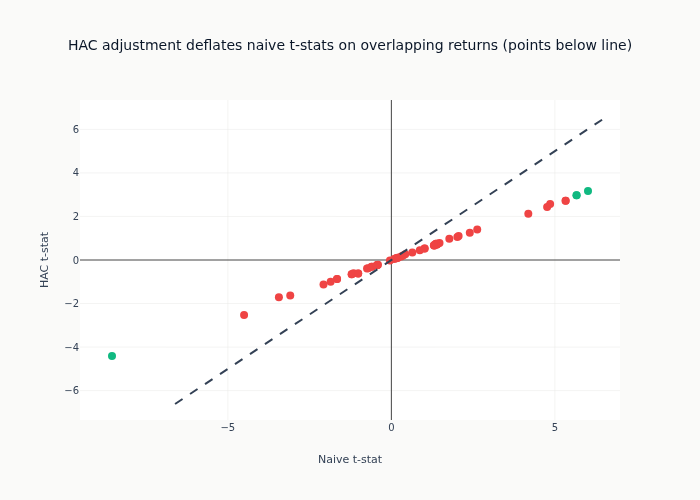

In [20]:
# Naive vs HAC t-statistics scatter
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_tstat"].to_list(),
        y=eval_summary["hac_tstat"].to_list(),
        mode="markers",
        text=eval_summary["feature"].to_list(),
        showlegend=False,
        marker=dict(
            color=[
                style.COLORS["positive"] if s else style.COLORS["negative"]
                for s in eval_summary["significant_fdr05"].to_list()
            ],
            size=8,
        ),
    )
)
_naive_max = eval_summary["naive_tstat"].max() if len(eval_summary) > 0 else 1.0
_hac_max = eval_summary["hac_tstat"].max() if len(eval_summary) > 0 else 1.0
max_t = max(abs(_naive_max or 1.0), abs(_hac_max or 1.0)) * 1.1
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=style.COLORS["neutral"]),
        showlegend=False,
    )
)
fig.update_layout(
    title="HAC adjustment deflates naive t-stats on overlapping returns (points below line)",
    xaxis_title="Naive t-stat",
    yaxis_title="HAC t-stat",
    template="ml4t",
    height=500,
)
fig.show()

**Interpretation**:
- Overlapping 5-day returns create strong autocorrelation in the IC series,
  so HAC adjustment is essential. Points below the diagonal confirm inflation
  of naive t-statistics.
- Calendar features (month, quarter, day-of-year) have no within-date variation
  and are excluded from IC computation — expected for cross-sectional analysis.
- Carry features predict total returns (`fwd_ret_5d`), consistent with carry
  capturing the structural roll yield component of futures returns.
- Highly correlated feature pairs (within momentum and carry families) suggest
  dimensionality reduction or feature selection before modeling.

In [21]:
# Build evaluation block for results JSON
family_ic = {}
for feat, stats in ic_results.items():
    family = assign_feature_family(feat)
    family_ic.setdefault(family, []).append(stats["mean_ic"])

family_avg_ic = {f: float(np.mean(ics)) for f, ics in family_ic.items()}

evaluation_block = {
    "primary_label": "fwd_ret_5d",
    "n_features_tested": len(tested_features),
    "n_significant_naive05": n_naive_sig,
    "n_significant_fdr05": n_significant,
    "inflation_factor": round(n_naive_sig / max(n_significant, 1), 1),
    "top_features": [
        {
            "name": row["feature"],
            "ic_mean": round(row["ic_mean"], 4),
            "hac_tstat": round(row["hac_tstat"], 2),
            "hac_pval": round(row["p_value"], 4),
        }
        for row in eval_summary.head(10).to_dicts()
    ],
    "max_pairwise_corr": round(max(abs(c) for _, _, c in high_corr_pairs), 3)
    if high_corr_pairs
    else 0.0,
    "corr_pairs_above_07": len(high_corr_pairs),
    "feature_family_avg_ic": {
        k: round(v, 4) for k, v in sorted(family_avg_ic.items(), key=lambda x: -abs(x[1]))
    },
    "carry_ic_validation": {
        "concept_claim": concept_claim,
        "best_carry_abs_ic": round(best_carry_ic, 4),
    },
}

## 9. Results Collection

In [22]:
def _git_commit_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True, timeout=5
        ).strip()
    except Exception:
        return "unknown"


results = {
    "case_study_id": STRATEGY_ID,
    "chapter": 8,
    "stage": "features",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": _git_commit_hash(),
    "notebook": f"case_studies/{STRATEGY_ID}/code/03_financial_features.py",
    "summary": {
        "n_features": n_features,
        "n_products": int(output_df["product"].n_unique()),
        "n_positions": int(output_df["position"].n_unique()),
        "n_rows": len(output_df),
        "date_range": [str(output_df["timestamp"].min()), str(output_df["timestamp"].max())],
    },
    "techniques": {
        "carry_features": "Raw carry, smoothed, z-score, sector-conditional rank",
        "momentum_features": "Multi-horizon returns, skip-month, time-series signals",
        "volatility_features": "Close-to-close, Yang-Zhang, variance ratio",
        "calendar_features": "Month sin/cos encoding, roll proximity, seasonal flag",
        "composite_features": "Carry-momentum composite, interaction term",
    },
    "diagnostics": {
        "feature_families": {
            "carry": len(carry_feats),
            "momentum": len(mom_feats),
            "volatility": len(vol_feats),
            "sharpe": len(sharpe_feats),
            "technical": len(tech_feats),
            "calendar": len(calendar_feats),
        },
    },
    "key_findings": [
        f"{n_features} features across 7 families for {output_df['product'].n_unique()} products",
        "Carry z-score (63d, 126d) captures product-level mean-reversion in term structure",
        "Seasonal sin/cos encoding for agriculture/energy products",
        "Sector-conditional carry rank normalizes within peer groups",
        "Skip-month momentum avoids short-term reversal contamination",
    ],
}

results["evaluation"] = evaluation_block

## 10. Summary Visualization

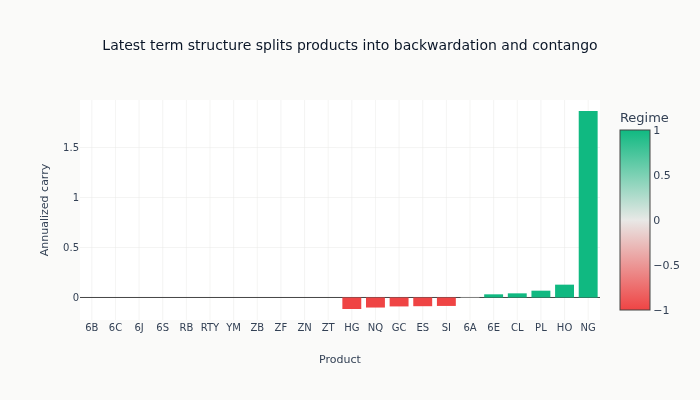

In [23]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Carry by product (latest date, front month)
latest = output_df.filter(
    (pl.col("timestamp") == pl.col("timestamp").max()) & (pl.col("position") == 0)
)

fig = px.bar(
    latest.sort("carry_pct").to_pandas(),
    x="product",
    y="carry_pct",
    color="carry_regime_num",
    color_continuous_scale=style.ml4t_diverging(),
    title="Latest term structure splits products into backwardation and contango",
    labels={"carry_pct": "Annualized carry", "product": "Product", "carry_regime_num": "Regime"},
)
fig.update_layout(template="ml4t", height=400)
fig.show()

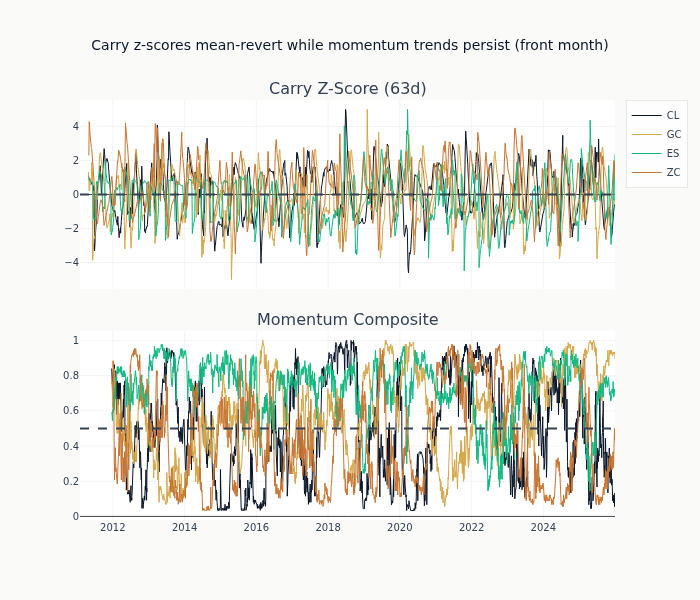

In [24]:
# Carry z-score time series for key products
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Carry Z-Score (63d)", "Momentum Composite"],
    vertical_spacing=0.1,
)

plot_data = output_df.filter(pl.col("position") == 0)

# Distinct categorical hue per product so the same product matches across subplots.
# Hand-picked from utils.style COLORS for maximum separation (the default
# categorical ramp puts two blue-family hues adjacent, which reads as one line).
key_products = ["CL", "GC", "ES", "ZC"]
product_colors = {
    "CL": style.COLORS["blue"],
    "GC": style.COLORS["amber"],
    "ES": style.COLORS["positive"],
    "ZC": style.COLORS["copper"],
}

for product in key_products:
    prod = plot_data.filter(pl.col("product") == product).sort("timestamp")
    if len(prod) > 0:
        fig.add_trace(
            go.Scatter(
                x=prod["timestamp"].to_list(),
                y=prod["carry_zscore_63d"].to_list(),
                name=f"{product}",
                line=dict(width=1, color=product_colors[product]),
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=prod["timestamp"].to_list(),
                y=prod["momentum_composite"].to_list(),
                name=f"{product}",
                line=dict(width=1, color=product_colors[product]),
                showlegend=False,
            ),
            row=2,
            col=1,
        )

fig.update_layout(
    template="ml4t",
    height=600,
    title_text="Carry z-scores mean-revert while momentum trends persist (front month)",
)
fig.add_hline(y=0, line_dash="dash", line_color=style.COLORS["neutral"], row=1, col=1)
fig.add_hline(y=0.5, line_dash="dash", line_color=style.COLORS["neutral"], row=2, col=1)
fig.show()

In [25]:
print("\n" + "=" * 60)
print("FEATURES SUMMARY")
print("=" * 60)
print(f"Features: {n_features}")
print(f"Rows: {len(output_df):,}")
print(f"Products: {output_df['product'].n_unique()}")
print(f"Positions: {sorted(output_df['position'].unique().to_list())}")
print(f"Date range: {output_df['timestamp'].min()} to {output_df['timestamp'].max()}")
print("\nNew features (vs prior version):")
print("  + carry_zscore_63d, carry_zscore_126d (time-series normalization)")
print("  + carry_rank_sector (sector-conditional ranking)")
print("  + skip_month_mom (t-252 to t-21, avoids reversal)")
print("  + carry_mom_interaction (carry z-score * momentum)")
print("  + month_sin, month_cos (seasonal encoding)")
print("  + roll_proximity (roll-week flag)")
print("  + is_seasonal_sector (agriculture/energy flag)")
print("  + day_of_year_norm, quarter")
print("=" * 60)


FEATURES SUMMARY
Features: 62
Rows: 310,948
Products: 30
Positions: [0, 1, 2]
Date range: 2011-02-01 to 2025-12-31

New features (vs prior version):
  + carry_zscore_63d, carry_zscore_126d (time-series normalization)
  + carry_rank_sector (sector-conditional ranking)
  + skip_month_mom (t-252 to t-21, avoids reversal)
  + carry_mom_interaction (carry z-score * momentum)
  + month_sin, month_cos (seasonal encoding)
  + roll_proximity (roll-week flag)
  + is_seasonal_sector (agriculture/energy flag)
  + day_of_year_norm, quarter


## Key Takeaways

1. **Carry z-scores** (63d and 126d) capture whether a product's term structure
   is historically stretched, enabling mean-reversion signals per Koijen et al. (2018)
2. **Sector-conditional ranking** normalizes carry within peer groups (energy vs
   agriculture vs financials), avoiding cross-sector scale contamination
3. **Seasonal features** via sin/cos encoding provide agriculture and energy
   products with calendar signals without hardcoding months
4. **Skip-month momentum** (252d - 21d) avoids the well-documented short-term
   reversal effect in the most recent month
5. **Carry-momentum interaction** captures confirming/conflicting signals between
   the two primary alpha sources

**Artifacts**: `features/financial.parquet`

**Next**: [`04_model_based_features`](04_model_based_features.ipynb) for ARIMA, FFT spectral,
and HMM regime features.